# Kart Telemetry — End-to-End Workflow (self-contained)

Sync a wheel-cam Insta360 Go 3S (`.gyroflow`) to a MyChron logger (`.xrk`),
segment by lap, and produce per-lap steering / speed / track telemetry —
**all in this one notebook**.

The full implementation is inlined below (Part 1), followed by the run on a
real session (Part 2). The only external import is the low-level `.gyroflow`
decoder (`load_gyroflow`) — base91→zlib→CBOR plumbing that isn't part of the
analysis itself. Everything else — sync, geometry, lap detection, steering
extraction, plotting — is defined here and is identical to the project's
test-covered modules.

**Contents**
- **Part 1 — the pipeline**: [Setup](#part-1) · [Sync implementation](#sync-impl) · [Lap + steering implementation](#lap-impl)
- **Part 2 — run it**: [Inputs](#inputs) · [Synchronize](#synchronize) · [Verify](#verify) · [Geometry](#geometry) · [Laps](#laps) · [Per-lap plots](#plots) · [Summary](#summary) · [What we learned](#learned)

<a id="part-1"></a>
## Part 1 — The pipeline

### Setup

Imports, the one low-level decoder dependency, and the session file paths.
Point `GYROFLOW` / `XRK` at your own files to re-run on a different session.

In [1]:
%matplotlib inline

import contextlib
import io
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, correlate, sosfiltfilt

# The only external piece: the .gyroflow decoder (base91 -> zlib -> CBOR -> IMU).
# It returns an ImuStream with .t, .gyro (rad/s), .accel (m/s^2), .sample_rate_hz.
from pipeline.extract_imu import ImuStream, load_gyroflow

# === EDIT THESE for your session ===========================================
GYROFLOW = Path("/Users/henry/Desktop/PRO_VID_20260511_145850_00_060.gyroflow")
XRK      = Path("/Users/henry/Desktop/xrk/a_a_XTreme_a_0619.xrk")
# ===========================================================================

<a id="sync-impl"></a>
### Sync implementation

Both streams independently measure the chassis yawing through corners — the
MyChron via GPS heading rate (`GPS_Yaw_Rate`), the wheel cam via the
low-frequency component of its gyro projected onto the steering-column axis.
Cross-correlating them recovers the clock offset between the two devices
(which drift independently — trusting wall-clocks doesn't work).

Geometry, for a wheel cam at any angle:

$$\omega_{\text{along column}} = \omega_{\text{steering}} + k \cdot \omega_{\text{chassis yaw}}$$

The column axis is the principal eigenvector of the gyro covariance (PCA);
$k = |\text{column} \cdot \text{world-up}|$ comes from the recording's own
gravity vector. The detected sign is folded into the stored axis so downstream
code never re-applies it. The cell below is the full sync module.

In [2]:
SYNC_RESAMPLE_HZ = 25.0       # match GPS_Yaw_Rate native rate
DEFAULT_MAX_LAG_S = 120.0     # search ±2 minutes
DEFAULT_LP_HZ = 0.3           # chassis yaw evolves on lap-scale (~30s); steering
                              # is at 0.3..3 Hz. Below 0.3 Hz isolates chassis.
EDGE_TRIM_S = 5.0             # trim IMU ends — Butterworth ringing + handling
                              # bumps (sticking/removing the camera) dominate
                              # the variance otherwise and pull the correlation.
QUIET_RATE_DPS = 2.0          # threshold for "wheel approximately stationary"
                              # samples used to estimate bias and gravity
GPS_YAW_GLITCH_DPS = 400.0    # |GPS_Yaw_Rate| above this is a GPS fix wobble,
                              # not real kart rotation — clean before use.
MIN_QUIET_SAMPLES = 50        # below this, gravity/bias geometry is unreliable


# ---------------------------------------------------------------------------
# stderr suppression for libxrk's cosmetic warnings
# ---------------------------------------------------------------------------

@contextlib.contextmanager
def _silence_stderr() -> Iterator[str]:
    """libxrk emits `Unknown units[...]` lines to stderr at file-load time
    for channels whose units aren't in its table. They're cosmetic; capture
    them so they don't clutter output, but yield the buffer so a caller can
    inspect it if a genuine error was reported. Restores stderr on exit.
    """
    old = sys.stderr
    buf = io.StringIO()
    sys.stderr = buf
    try:
        yield buf
    finally:
        sys.stderr = old


def load_xrk(xrk_path: Path):
    """Wrap libxrk.aim_xrk(). Returns the LogFile object.

    The `import libxrk` is deferred (function-local) so that importing this
    module — e.g. to reuse the cross-correlation helpers in tests — doesn't
    hard-require the optional libxrk dependency until a file is actually read.
    """
    import libxrk
    with _silence_stderr() as captured:
        try:
            return libxrk.aim_xrk(str(xrk_path))
        except Exception:
            # Surface anything libxrk printed to stderr — it's the only place
            # the C layer reports decode failures.
            noise = captured.getvalue().strip()
            if noise:
                print(noise, file=sys.stderr)
            raise


# ---------------------------------------------------------------------------
# Body-frame geometry from the IMU
# ---------------------------------------------------------------------------

def _quiet_mask(gyro: np.ndarray, quiet_rate_dps: float = QUIET_RATE_DPS) -> np.ndarray:
    """Boolean mask of samples where the wheel is ≈stationary."""
    mag = np.linalg.norm(gyro, axis=1)
    return mag < np.deg2rad(quiet_rate_dps)


def detect_column_axis(gyro: np.ndarray) -> np.ndarray:
    """PCA of gyro covariance: the principal eigenvector is the wheel
    rotation axis in body frame (= steering column direction).

    Works for any wheel-mounted camera regardless of how it's angled.
    Sign is canonicalised so the +Z-dominant direction wins; the actual
    sign convention for steering (left/right positive) is then resolved
    by `cross_correlate_offset` returning `sign = ±1`, which `sync_imu_to_xrk`
    folds back into the stored axis.
    """
    centred = gyro - gyro.mean(axis=0)
    cov = centred.T @ centred / len(centred)
    _, evecs = np.linalg.eigh(cov)
    n = evecs[:, -1]
    if n[2] < 0:
        n = -n
    return n


def estimate_quiet_bias(gyro: np.ndarray,
                        quiet_rate_thresh_dps: float = QUIET_RATE_DPS,
                        ) -> np.ndarray:
    """Per-axis gyro bias from low-rate samples. Even a session with
    ~5% quiet moments gives a clean estimate (typically 23k+ samples
    at 1 kHz × 25s of stillness across the recording).

    Returns zeros if there are no quiet samples — callers should check
    the quiet-sample count (see `count_quiet_samples`) to know whether
    the estimate is trustworthy rather than treating zeros as a real bias.
    """
    quiet = _quiet_mask(gyro, quiet_rate_thresh_dps)
    if not quiet.any():
        return np.zeros(3)
    return gyro[quiet].mean(axis=0)


def count_quiet_samples(gyro: np.ndarray,
                        quiet_rate_dps: float = QUIET_RATE_DPS) -> int:
    """How many ≈stationary samples the recording contains. Used to decide
    whether the gravity/bias geometry is trustworthy."""
    return int(_quiet_mask(gyro, quiet_rate_dps).sum())


def estimate_column_tilt_factor(stream: ImuStream, column_axis: np.ndarray,
                                quiet_rate_dps: float = QUIET_RATE_DPS,
                                ) -> float:
    """Compute k = |column · world_up| from the recording's own gravity.

    The wheel-mounted IMU column projection sees both steering and
    chassis yaw:

        ω_along_column = ω_steering + k · ω_chassis_yaw

    where k is the cosine of the column tilt from vertical, fixed by
    chassis-and-mount geometry. With both projected onto the same
    1D axis, k can in principle be regressed from the data — but
    GPS_Yaw_Rate has measurement noise, which biases OLS slope toward
    zero (errors-in-variables attenuation). Geometry is exact.

    Returns the magnitude; the sign is folded into the stored column axis.
    Returns NaN if there are no quiet samples — k=NaN propagates loudly
    instead of a silent 0.0 that would disable chassis-yaw subtraction
    while looking like a real horizontal-column geometry.
    """
    quiet = _quiet_mask(stream.gyro, quiet_rate_dps)
    if not quiet.any():
        return float("nan")
    g_body = stream.accel[quiet].mean(axis=0)
    norm = np.linalg.norm(g_body)
    if norm < 1e-6:
        return float("nan")
    world_up = -g_body / norm
    return float(abs(np.dot(column_axis, world_up)))


def chassis_yaw_from_imu(stream: ImuStream,
                         lowpass_hz: float = DEFAULT_LP_HZ,
                         edge_trim_s: float = EDGE_TRIM_S,
                         ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Returns (t [s], chassis_yaw_rate [rad/s], column_axis, gyro_bias).

    `chassis_yaw_rate` here is the low-pass-filtered column-axis projection
    of the gyro. Steering inputs (faster than `lowpass_hz`) are removed so
    what remains tracks GPS yaw rate.

    `edge_trim_s` trims that many seconds off each end — the LP filter has
    ringing at the boundaries, and the very start/end usually contain
    camera-handling transients that aren't real motion. The trim is skipped
    (rather than emptying the signal) when it's 0 or would consume the whole
    recording, so short clips and `edge_trim_s=0` still work.
    """
    bias = estimate_quiet_bias(stream.gyro)
    gyro = stream.gyro - bias
    n_col = detect_column_axis(gyro)
    rate_along_col = gyro @ n_col

    fs = stream.sample_rate_hz
    sos = butter(3, lowpass_hz / (fs / 2.0), btype="low", output="sos")
    yaw_lp = sosfiltfilt(sos, rate_along_col)

    trim = int(edge_trim_s * fs)
    if trim <= 0 or 2 * trim >= len(stream.t):
        return stream.t, yaw_lp, n_col, bias
    return stream.t[trim:-trim], yaw_lp[trim:-trim], n_col, bias


# ---------------------------------------------------------------------------
# XRK side
# ---------------------------------------------------------------------------

def clean_gps_yaw_dps(t_gps: np.ndarray, yr_dps: np.ndarray,
                      glitch_threshold_dps: float = GPS_YAW_GLITCH_DPS,
                      ) -> np.ndarray:
    """Remove GPS fix-instability spikes from a yaw-rate trace (deg/s).

    GPS_Yaw_Rate occasionally reports physically impossible values (we've
    seen 2500°/s) when the fix wobbles, and may contain NaN/inf. Both are
    treated as bad and linearly interpolated over from neighbouring good
    samples. Only the bad samples are replaced (good samples are untouched).

    This is the single source of yaw cleaning, used by BOTH the
    cross-correlation sync and the steering subtraction, so the two never
    disagree about which samples are real.

    If every sample is bad, returns zeros (no usable yaw information).
    """
    yr = np.asarray(yr_dps, dtype=float).copy()
    bad = ~np.isfinite(yr) | (np.abs(yr) > glitch_threshold_dps)
    if bad.all():
        return np.zeros_like(yr)
    if bad.any():
        good = ~bad
        yr[bad] = np.interp(t_gps[bad], t_gps[good], yr[good])
    return yr


def chassis_yaw_from_xrk(log) -> tuple[np.ndarray, np.ndarray]:
    """Returns (t [s], yaw_rate [rad/s]) from XRK `GPS_Yaw_Rate`, glitch-cleaned.

    The cleaning happens here at the source so the cross-correlation sync
    aligns against the same de-spiked signal the steering extraction uses.
    """
    tbl = log.channels.get("GPS_Yaw_Rate")
    if tbl is None:
        raise ValueError("XRK has no GPS_Yaw_Rate channel — cannot sync.")
    t_ms = np.asarray(tbl["timecodes"], dtype=np.float64)
    yr_dps = np.asarray(tbl["GPS_Yaw_Rate"], dtype=np.float64)
    t_s = t_ms / 1000.0
    return t_s, np.deg2rad(clean_gps_yaw_dps(t_s, yr_dps))


# ---------------------------------------------------------------------------
# Cross-correlation
# ---------------------------------------------------------------------------

def _robust_normalise(x: np.ndarray) -> np.ndarray:
    """Zero-median, MAD-scaled. Resistant to outlier spikes that would
    dominate a std-based normalization.

    The scale floor is relative to the signal, not an absolute 1e-12: when
    the signal is flat over >50% of its samples the MAD collapses to 0, so
    we fall back to the std; a truly constant signal returns zeros (it
    carries no alignment information and must not be divided by ~0, which
    would blow a single spike up to ~1e12 and hijack the correlation).
    """
    x = np.asarray(x, dtype=float)
    m = np.median(x)
    centred = x - m
    mad = np.median(np.abs(centred))
    s = 1.4826 * mad
    if s <= 1e-9:                       # MAD collapsed (mostly-flat signal)
        s = float(centred.std())
    if s <= 1e-12:                      # genuinely constant signal
        return np.zeros_like(x)
    return centred / s


def cross_correlate_offset(t_imu: np.ndarray, yaw_imu: np.ndarray,
                           t_xrk: np.ndarray, yaw_xrk: np.ndarray,
                           max_lag_s: float = DEFAULT_MAX_LAG_S,
                           fs: float = SYNC_RESAMPLE_HZ,
                           ) -> tuple[float, float, int]:
    """Find the time offset that best aligns two yaw-rate signals.

    Returns (offset_imu_to_xrk_s, peak_normalized_corr, sign).
      - offset: add this to IMU `t` to land on XRK time.
      - peak: |normalized cross-correlation| at the best lag, genuinely in
        [0, 1] (Pearson-style: divided by the product of the per-lag window
        L2 norms, so the `< 0.5 = weak` gate downstream is calibrated).
      - sign: ±1; if -1, the IMU signal had to be flipped (PCA-detected
        column axis points opposite to GPS-yaw convention).
    """
    dt = 1.0 / fs

    # Resample each onto its own uniform grid
    grid_i = np.arange(t_imu[0], t_imu[-1] + dt, dt)
    grid_x = np.arange(t_xrk[0], t_xrk[-1] + dt, dt)
    y_i = _robust_normalise(np.interp(grid_i, t_imu, yaw_imu))
    y_x = _robust_normalise(np.interp(grid_x, t_xrk, yaw_xrk))

    # Numerator: sliding dot product. correlate(a,b)[k] = Σ a[n]·b[n-lag].
    raw_corr = correlate(y_i, y_x, mode="full")

    # Denominator: per-lag product of the two overlapping windows' L2 norms,
    # computed as sliding sums of squares (correlate with an ones kernel).
    # This makes the result a true normalized cross-correlation, bounded
    # to [-1, 1] by Cauchy-Schwarz — unlike dividing by the overlap count.
    energy_i = correlate(y_i ** 2, np.ones_like(y_x), mode="full")
    energy_x = correlate(np.ones_like(y_i), y_x ** 2, mode="full")
    denom = np.sqrt(np.maximum(energy_i, 0.0) * np.maximum(energy_x, 0.0))
    ncc = np.where(denom > 1e-12, raw_corr / np.maximum(denom, 1e-12), 0.0)

    lag_samples = np.arange(-len(y_x) + 1, len(y_i))
    lag_s = lag_samples * dt

    # Require ≥1s overlap and constrain to ±max_lag_s.
    overlap = np.minimum.reduce([
        len(y_i) - np.maximum(lag_samples, 0),
        len(y_x) + np.minimum(lag_samples, 0),
    ])
    valid = (overlap >= int(fs * 1.0)) & (np.abs(lag_s) <= max_lag_s)
    ncc = np.where(valid, ncc, 0.0)

    best = int(np.argmax(np.abs(ncc)))
    sign = int(np.sign(ncc[best])) or 1
    peak = float(np.abs(ncc[best]))
    best_lag_s = float(lag_s[best])

    # Translate cross-correlation lag → clock offset on IMU time:
    #   y_i(t_imu_grid[n]) ≈ y_x(t_xrk_grid[n - lag])
    #   → t_x = t_i + (t_xrk[0] - t_imu[0] - lag·dt)
    offset_imu_to_xrk_s = float(t_xrk[0] - t_imu[0] - best_lag_s)
    return offset_imu_to_xrk_s, peak, sign


# ---------------------------------------------------------------------------
# Top-level
# ---------------------------------------------------------------------------

@dataclass
class SyncedXrk:
    """Result of `sync_imu_to_xrk()`. Everything downstream needs to align
    the IMU stream to XRK and extract clean steering.
    """
    gyroflow_path: Path
    xrk_path: Path
    # Sync timing
    offset_imu_to_xrk_s: float    # add to IMU `t` to land on XRK clock
    corr_peak: float              # [0, 1] normalized cross-correlation (>0.5 confident)
    sign: int                     # detected ±1; ALREADY folded into column_axis below
    # Body-frame geometry (from the IMU recording)
    column_axis: np.ndarray       # sign-corrected unit axis; gyro @ column_axis is
                                  # the chassis-yaw-positive steering rate directly
    column_tilt_factor: float     # k = |column · world_up|, used to subtract chassis
                                  # yaw; NaN if geometry could not be estimated
    gyro_bias: np.ndarray         # per-axis rad/s, from quiet samples
    quiet_sample_count: int       # # of ≈stationary samples backing bias/tilt
    # Loaded inputs, so callers don't reload them
    imu_stream: object            # extract_imu.ImuStream (the loaded wheel IMU)
    xrk_log: object               # libxrk.LogFile

    @property
    def column_tilt_deg(self) -> float:
        """Column tilt from world-vertical (degrees), for reporting."""
        return float(np.rad2deg(np.arccos(np.clip(self.column_tilt_factor, -1.0, 1.0))))

    @property
    def geometry_reliable(self) -> bool:
        """True if there were enough quiet samples to trust bias + tilt."""
        return (self.quiet_sample_count >= MIN_QUIET_SAMPLES
                and np.isfinite(self.column_tilt_factor))


def sync_imu_to_xrk(gyroflow_path: Path, xrk_path: Path,
                    *, max_lag_s: float = DEFAULT_MAX_LAG_S,
                    lowpass_hz: float = DEFAULT_LP_HZ,
                    ) -> SyncedXrk:
    """End-to-end sync. Loads both files, runs cross-correlation, returns
    everything downstream tools need (including the loaded IMU stream, so
    callers don't parse the .gyroflow a second time).
    """
    from pipeline.extract_imu import load_gyroflow

    stream = load_gyroflow(gyroflow_path, source="wheel")
    log = load_xrk(xrk_path)

    t_imu, yaw_imu, n_col, bias = chassis_yaw_from_imu(stream, lowpass_hz=lowpass_hz)
    t_xrk, yaw_xrk = chassis_yaw_from_xrk(log)
    offset, peak, sign = cross_correlate_offset(
        t_imu, yaw_imu, t_xrk, yaw_xrk, max_lag_s=max_lag_s,
    )

    # Fold the detected sign into the stored axis so consumers never re-apply it.
    column_axis = sign * n_col
    tilt = estimate_column_tilt_factor(stream, column_axis)
    n_quiet = count_quiet_samples(stream.gyro)

    if n_quiet < MIN_QUIET_SAMPLES or not np.isfinite(tilt):
        warnings.warn(
            f"Only {n_quiet} quiet samples in {gyroflow_path.name}; gyro bias "
            f"and column-tilt (k={tilt:.3f}) geometry are unreliable. Steering "
            f"output may retain chassis yaw. Capture a few seconds of stillness "
            f"(wheel centred, kart stopped) for a trustworthy result.",
            stacklevel=2,
        )

    return SyncedXrk(
        gyroflow_path=gyroflow_path,
        xrk_path=xrk_path,
        offset_imu_to_xrk_s=offset,
        corr_peak=peak,
        sign=sign,
        column_axis=column_axis,
        column_tilt_factor=tilt,
        gyro_bias=bias,
        quiet_sample_count=n_quiet,
        imu_stream=stream,
        xrk_log=log,
    )

<a id="lap-impl"></a>
### Lap detection + steering extraction

Steering = the column projection minus $k \cdot$ GPS-yaw, integrated, then a
light high-pass to clean residual drift — restricted to the IMU/XRK time
overlap so no chassis yaw is fabricated outside the GPS span. Laps come from
the XRK beacon markers when they look sane, else GPS return-to-start
detection. The cell below is the full per-lap module.

In [3]:
LAP_DETECT_RADIUS_M = 25.0       # "near start" threshold
LAP_DETECT_MIN_DURATION_S = 15.0  # discard suspiciously short "laps"
GPS_MOVING_THRESHOLD_MPS = 5.0 / 3.6  # 5 km/h, ~minimum to consider "on track"


def _gps_distance_to_ref_m(lat: np.ndarray, lon: np.ndarray,
                           lat_ref: float, lon_ref: float) -> np.ndarray:
    """Equirectangular small-region approximation. Accurate to <1% for any
    kart track (always < 1 km across)."""
    R = 6_371_000.0
    dlat = np.deg2rad(lat - lat_ref)
    dlon = np.deg2rad(lon - lon_ref) * np.cos(np.deg2rad(lat_ref))
    return R * np.hypot(dlat, dlon)


def detect_laps_from_gps(log, radius_m: float = LAP_DETECT_RADIUS_M,
                         ) -> list[tuple[float, float]]:
    """Return [(start_time_s, end_time_s), ...] per detected lap.

    Algorithm: take the first moving sample (GPS_Speed > 5 km/h) as the
    reference. Walk the trace; whenever the kart returns within `radius_m`
    of the reference AFTER having left it, declare a lap.
    """
    if "GPS Latitude" not in log.channels or "GPS Longitude" not in log.channels:
        return []
    lat_tbl = log.channels["GPS Latitude"]
    lon_tbl = log.channels["GPS Longitude"]
    t = np.asarray(lat_tbl["timecodes"], dtype=np.float64) / 1000.0
    lat = np.asarray(lat_tbl["GPS Latitude"], dtype=np.float64)
    # Longitude is a separate channel table with its own (possibly different
    # length / slightly misaligned) timecodes — align it onto the lat grid
    # rather than assuming index-for-index correspondence.
    t_lon = np.asarray(lon_tbl["timecodes"], dtype=np.float64) / 1000.0
    lon = np.interp(t, t_lon, np.asarray(lon_tbl["GPS Longitude"], dtype=np.float64))

    if "GPS Speed" in log.channels:
        sp_tbl = log.channels["GPS Speed"]
        t_sp = np.asarray(sp_tbl["timecodes"], dtype=np.float64) / 1000.0
        spd = np.asarray(sp_tbl["GPS Speed"], dtype=np.float64)  # m/s
        spd_on_gps = np.interp(t, t_sp, spd)
    else:
        spd_on_gps = np.full_like(t, 10.0)  # assume moving if no speed channel

    moving = np.where(spd_on_gps > GPS_MOVING_THRESHOLD_MPS)[0]
    if len(moving) < 2:
        return []
    i_ref = moving[0]
    dist = _gps_distance_to_ref_m(lat, lon, lat[i_ref], lon[i_ref])

    laps: list[tuple[float, float]] = []
    lap_start_t = t[i_ref]
    away = False
    for i in range(i_ref + 1, len(t)):
        if dist[i] > radius_m * 2:
            away = True
        elif away and dist[i] < radius_m:
            lap_end_t = t[i]
            # Always re-arm and restart timing on a return-to-start, whether or
            # not the window was long enough to count. Leaving `away` True on a
            # rejected short window (e.g. an aborted launch / nose-out) would
            # measure the next real lap from a stale start time.
            if lap_end_t - lap_start_t >= LAP_DETECT_MIN_DURATION_S:
                laps.append((lap_start_t, lap_end_t))
            lap_start_t = lap_end_t
            away = False
    return laps


def choose_lap_windows(sync: SyncedXrk, force_source: str = "auto"
                       ) -> tuple[list[tuple[float, float]], str]:
    """Decide whether to use XRK beacon laps or GPS-detected laps.

    `force_source` ∈ {"auto", "xrk", "gps"}. In auto mode, fall back to
    GPS detection if the XRK has ≤2 lap markers OR any lap >120s (real
    kart laps are 30–90s; a long one indicates missed beacon crossings).

    Returns (lap_windows, source_used) where source_used is "xrk" or "gps".
    """
    log = sync.xrk_log
    xrk_starts = log.laps["start_time"].to_pylist()
    xrk_ends = log.laps["end_time"].to_pylist()
    xrk_durations = [(e - s) / 1000.0 for s, e in zip(xrk_starts, xrk_ends)]

    use_gps = (
        force_source == "gps"
        or (force_source == "auto"
            and (len(xrk_durations) <= 2 or (xrk_durations and max(xrk_durations) > 120)))
    )
    if use_gps:
        gps = detect_laps_from_gps(log)
        if not gps:
            raise SystemExit(
                "GPS lap detection found nothing usable. "
                "Try --lap-source xrk to use the XRK markers anyway."
            )
        return gps, "gps"
    return [(s / 1000.0, e / 1000.0) for s, e in zip(xrk_starts, xrk_ends)], "xrk"


# ---------------------------------------------------------------------------
# Steering extraction (chassis-yaw subtracted)
# ---------------------------------------------------------------------------

DEFAULT_STEERING_HP_HZ = 0.05    # residual drift removal after subtraction


def _hp_filter(angle_deg: np.ndarray, fs: float, hp_hz: float) -> np.ndarray:
    """Zero-phase high-pass. Falls back to mean-removal for clips too short
    for sosfiltfilt's padding requirement (instead of raising)."""
    sos = butter(3, hp_hz / (fs / 2), btype="high", output="sos")
    try:
        return sosfiltfilt(sos, angle_deg)
    except ValueError:
        return angle_deg - angle_deg.mean() if angle_deg.size else angle_deg


def steering_from_synced(stream: ImuStream, sync: SyncedXrk,
                         hp_hz: float = DEFAULT_STEERING_HP_HZ,
                         ) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Returns (t_xrk [s], steering_angle [deg], steering_rate [deg/s])
    over the IMU/XRK time OVERLAP, on the XRK clock.

    Method:
        ω_along_col = (gyro - bias) · column_axis     # sign already folded in
        ω_steering  = ω_along_col − k · GPS_Yaw_Rate(interpolated)
        angle       = trapezoidal integral of ω_steering, HP-filtered

    Only the portion of the IMU recording that overlaps the GPS time span is
    returned. np.interp would otherwise flat-extrapolate GPS_Yaw_Rate (hold
    the first/last value) across the IMU lead-in/tail, fabricating chassis
    yaw and biasing the integrated angle of the laps adjacent to the span
    edges. Lap windows always fall inside the GPS span, so nothing real is lost.

    HP at `hp_hz` is a small safety net for residual integration drift.
    """
    # 1. IMU column projection on XRK clock (sign already folded into the axis)
    gyro = stream.gyro - sync.gyro_bias
    rate_along_col = gyro @ sync.column_axis            # rad/s
    t_imu_xrk = stream.t + sync.offset_imu_to_xrk_s

    # 2. GPS yaw rate from XRK, already glitch-cleaned at the source by
    #    chassis_yaw_from_xrk; re-clean here defensively (cheap, idempotent)
    #    in case a caller passes a hand-built log.
    yr_tbl = sync.xrk_log.channels["GPS_Yaw_Rate"]
    t_gps = np.asarray(yr_tbl["timecodes"], dtype=np.float64) / 1000.0
    yr_dps = clean_gps_yaw_dps(t_gps, np.asarray(yr_tbl["GPS_Yaw_Rate"], dtype=np.float64))

    # 3. Map GPS yaw onto the IMU clock, but ONLY within the GPS-covered span.
    yr_on_imu = np.interp(t_imu_xrk, t_gps, yr_dps, left=np.nan, right=np.nan)
    in_range = np.isfinite(yr_on_imu)
    if not in_range.any():
        raise ValueError(
            "IMU and XRK time ranges do not overlap after sync "
            f"(offset {sync.offset_imu_to_xrk_s:+.1f}s); cannot extract steering."
        )

    # Restrict everything to the contiguous in-range slice. The slice is
    # contiguous because t_imu_xrk is monotonic and the GPS span is an interval.
    t_imu_xrk = t_imu_xrk[in_range]
    t_local = stream.t[in_range]
    rate_along_col = rate_along_col[in_range]
    yr_rps = np.deg2rad(yr_on_imu[in_range])

    # 4. Subtract k · GPS yaw. If geometry was unreliable (k=NaN, no quiet
    #    samples) fall back to no subtraction rather than poisoning everything
    #    with NaN — sync_imu_to_xrk already warned the user in that case.
    k = sync.column_tilt_factor if np.isfinite(sync.column_tilt_factor) else 0.0
    steer_rate_rps = rate_along_col - k * yr_rps

    # 5. Trapezoidal integral on the (monotonic) in-range time base.
    angle_rad = np.zeros_like(steer_rate_rps)
    angle_rad[1:] = np.cumsum(0.5 * (steer_rate_rps[1:] + steer_rate_rps[:-1])
                              * np.diff(t_local))
    angle_deg = _hp_filter(np.rad2deg(angle_rad), stream.sample_rate_hz, hp_hz)

    return t_imu_xrk, angle_deg, np.rad2deg(steer_rate_rps)


# ---------------------------------------------------------------------------
# Per-lap slicing
# ---------------------------------------------------------------------------

@dataclass
class LapData:
    """One lap's worth of synchronized telemetry. Times are XRK-clock seconds."""
    lap_index: int                          # 0-based index into the lap list
    t_start: float
    t_end: float
    duration: float
    # IMU side, sliced to the lap window
    t_imu: np.ndarray
    steering_angle_deg: np.ndarray
    steering_rate_dps: np.ndarray
    # XRK side, one entry per channel that has data in this window
    xrk_channels: dict[str, np.ndarray]
    xrk_t: dict[str, np.ndarray]

    @property
    def label(self) -> str:
        return f"lap {self.lap_index}"

    @property
    def has_imu(self) -> bool:
        return self.steering_angle_deg.size > 0


def extract_lap(stream: ImuStream, sync: SyncedXrk,
                lap_window: tuple[float, float], lap_index: int,
                *, steering: tuple[np.ndarray, np.ndarray, np.ndarray] | None = None,
                ) -> LapData:
    """Slice one lap out of the synchronized session.

    `steering` is the (t_xrk, angle_deg, rate_dps) tuple from
    `steering_from_synced`. Pass it in to compute the (expensive,
    full-recording) steering integral ONCE and reuse it across every lap;
    if omitted it is computed here (convenient for one-off single-lap use).
    """
    t_start, t_end = lap_window
    t_start_ms = int(t_start * 1000)
    t_end_ms = int(t_end * 1000)

    if steering is None:
        steering = steering_from_synced(stream, sync)
    t_imu_xrk, ang_deg, rate_dps = steering

    # Half-open [t_start, t_end) so adjacent laps don't share a boundary sample.
    mask = (t_imu_xrk >= t_start) & (t_imu_xrk < t_end)

    xrk_ch: dict[str, np.ndarray] = {}
    xrk_t: dict[str, np.ndarray] = {}
    for name, tbl in sync.xrk_log.channels.items():
        if tbl.num_rows == 0:
            continue
        # Cast to int64 so a chunked-arrow object dtype can't break comparisons,
        # and use searchsorted (timecodes are monotonic) instead of a full mask.
        t_ms = np.asarray(tbl["timecodes"], dtype=np.int64)
        lo = int(np.searchsorted(t_ms, t_start_ms, side="left"))
        hi = int(np.searchsorted(t_ms, t_end_ms, side="left"))  # half-open
        if hi <= lo:
            continue
        col = [c for c in tbl.column_names if c != "timecodes"][0]
        xrk_ch[name] = np.asarray(tbl[col])[lo:hi]
        xrk_t[name] = t_ms[lo:hi] / 1000.0

    return LapData(
        lap_index=lap_index,
        t_start=t_start, t_end=t_end, duration=t_end - t_start,
        t_imu=t_imu_xrk[mask],
        steering_angle_deg=ang_deg[mask],
        steering_rate_dps=rate_dps[mask],
        xrk_channels=xrk_ch,
        xrk_t=xrk_t,
    )


# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_lap(lap: LapData, out_path: Path, *, title: str = "") -> None:
    """Render a 4-panel summary PNG for one lap.

    Panels:
        - top-left   : steering angle (deg) vs lap-relative time
        - middle-left: kart yaw rate (deg/s) from XRK GPS_Yaw_Rate
        - bottom-left: GPS speed (km/h)
        - right      : GPS track lat/lon overlay, colored by speed
    """
    fig = plt.figure(figsize=(15, 10), constrained_layout=True)
    try:
        gs = fig.add_gridspec(3, 2, width_ratios=[2, 1])
        ax_steer = fig.add_subplot(gs[0, 0])
        ax_yaw = fig.add_subplot(gs[1, 0], sharex=ax_steer)
        ax_speed = fig.add_subplot(gs[2, 0], sharex=ax_steer)
        ax_map = fig.add_subplot(gs[:, 1])

        t0 = lap.t_start

        # Steering angle
        ax_steer.plot(lap.t_imu - t0, lap.steering_angle_deg, lw=0.8, color="tab:blue")
        ax_steer.axhline(0, color="black", lw=0.4)
        ax_steer.set_ylabel("steering angle (deg)")
        ax_steer.set_title(f"Lap {lap.lap_index}  —  {lap.duration:.2f}s  ({title})")
        ax_steer.grid(alpha=0.3)

        # Kart yaw rate
        if "GPS_Yaw_Rate" in lap.xrk_channels:
            ax_yaw.plot(lap.xrk_t["GPS_Yaw_Rate"] - t0,
                        lap.xrk_channels["GPS_Yaw_Rate"],
                        lw=0.9, color="tab:orange")
        ax_yaw.axhline(0, color="black", lw=0.4)
        ax_yaw.set_ylabel("kart yaw rate (deg/s)")
        ax_yaw.grid(alpha=0.3)

        # GPS speed (m/s in raw XRK → km/h for display)
        if "GPS Speed" in lap.xrk_channels:
            ax_speed.plot(lap.xrk_t["GPS Speed"] - t0,
                          lap.xrk_channels["GPS Speed"] * 3.6,
                          lw=0.9, color="tab:green")
            ax_speed.set_ylabel("GPS speed (km/h)")
        ax_speed.set_xlabel("lap time (s)")
        ax_speed.grid(alpha=0.3)

        # Track map
        if "GPS Latitude" in lap.xrk_channels and "GPS Longitude" in lap.xrk_channels:
            t_lat = lap.xrk_t["GPS Latitude"]
            lat = lap.xrk_channels["GPS Latitude"]
            # Align longitude onto the latitude samples (independent channels).
            lon = np.interp(t_lat, lap.xrk_t["GPS Longitude"],
                            lap.xrk_channels["GPS Longitude"])
            if "GPS Speed" in lap.xrk_channels:
                sp_kmh = np.interp(t_lat, lap.xrk_t["GPS Speed"],
                                   lap.xrk_channels["GPS Speed"]) * 3.6
                sc = ax_map.scatter(lon, lat, c=sp_kmh, s=4, cmap="viridis")
                plt.colorbar(sc, ax=ax_map, label="speed (km/h)", shrink=0.7)
            else:
                ax_map.plot(lon, lat, lw=1.0)
            ax_map.set_xlabel("longitude")
            ax_map.set_ylabel("latitude")
            ax_map.set_title("track (GPS)")
            ax_map.set_aspect("equal", adjustable="datalim")
            ax_map.grid(alpha=0.3)
        else:
            ax_map.text(0.5, 0.5, "no GPS", ha="center", va="center",
                        transform=ax_map.transAxes)

        fig.savefig(out_path, dpi=110, bbox_inches="tight")
    finally:
        plt.close(fig)


# ---------------------------------------------------------------------------
# Summary stats
# ---------------------------------------------------------------------------

def lap_summary(lap: LapData) -> dict[str, float]:
    """One-liner per-lap stats. Used for the console table and RESULTS.md.

    Guards every reduction against an empty array — a lap window with no
    overlapping IMU samples (or no GPS in range) yields NaN rather than a
    `zero-size array to reduction` crash that would abort an `--all` run.
    """
    steer = lap.steering_angle_deg
    out: dict[str, float] = {
        "duration_s": lap.duration,
        "peak_steer_deg": float(np.abs(steer).max()) if steer.size else float("nan"),
    }
    if "GPS_Yaw_Rate" in lap.xrk_channels:
        yr = lap.xrk_channels["GPS_Yaw_Rate"]
        clean = yr[np.abs(yr) <= GPS_YAW_GLITCH_DPS]
        out["peak_yaw_rate_dps"] = float(np.abs(clean).max()) if clean.size else float("nan")
    if "GPS Speed" in lap.xrk_channels and lap.xrk_channels["GPS Speed"].size:
        sp = lap.xrk_channels["GPS Speed"]
        out["peak_speed_kmh"] = float(sp.max() * 3.6)
        out["mean_speed_kmh"] = float(sp.mean() * 3.6)
    return out


# ---------------------------------------------------------------------------
# CLI
# ---------------------------------------------------------------------------

<a id="part-2"></a>
## Part 2 — Run it

<a id="inputs"></a>
### Inputs

Load both files and show what's in them. The `.gyroflow` carries the raw IMU
at 1 kHz; the `.xrk` has 30+ channels at varying rates (GPS @ 25 Hz).

In [4]:
stream = load_gyroflow(GYROFLOW, source="wheel")
print("IMU stream:")
print(f"  samples:      {len(stream.t):,}")
print(f"  duration:     {stream.t[-1]:.1f} s")
print(f"  sample rate:  {stream.sample_rate_hz:.1f} Hz")
print(f"  orientation:  {stream.orientation}")
print()

log = load_xrk(XRK)   # defined inline above; silences libxrk's cosmetic warnings
m = log.metadata
print("XRK log:")
print(f"  recording:    {m['Log Date']} {m['Log Time']}")
print(f"  driver:       {m['Driver']!r} @ track {m['Venue']!r}")
print(f"  logger model: {m['Logger Model ID']}, ID {m['Logger ID']}")
print(f"  duration:     {log.laps['end_time'][-1].as_py()/1000:.1f} s")
print(f"  channels:     {len(log.channels)}")
print(f"  XRK laps:     {log.laps.num_rows} (beacon-detected — often unreliable; see Laps)")

IMU stream:
  samples:      519,179
  duration:     519.2 s
  sample rate:  1000.0 Hz
  orientation:  yXZ

Unknown units[8] for b'Distance Lap\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomY\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomZ\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
XRK log:
  recording:    05/11/2026 14:59:21
  driver:       'a' @ track 'XTreme'
  logger model: 787, ID 83056659
  duration:     290.0 s
  channels:     32
  XRK laps:     2 (beacon-detected — often unreliable; see Laps)


<a id="synchronize"></a>
### Synchronize

Run the cross-correlation. `corr_peak` is a genuine normalized
cross-correlation in [0, 1] (>0.5 is a confident match).

In [5]:
sync = sync_imu_to_xrk(GYROFLOW, XRK)

print(f"  offset (add to IMU t):  {sync.offset_imu_to_xrk_s:+8.3f} s")
print(f"  peak |correlation|:     {sync.corr_peak:8.4f}   "
      f"({'STRONG' if sync.corr_peak > 0.5 else 'WEAK — check'})")
print(f"  sign:                   {sync.sign:+8d}   (folded into column_axis)")
print(f"  column axis (body):     ({sync.column_axis[0]:+.3f}, "
      f"{sync.column_axis[1]:+.3f}, {sync.column_axis[2]:+.3f})")
print(f"  column tilt:            {sync.column_tilt_deg:.1f}° from world-vertical")
print(f"  tilt factor k:          {sync.column_tilt_factor:.4f}")
print(f"  quiet samples:          {sync.quiet_sample_count}   "
      f"(geometry reliable: {sync.geometry_reliable})")
print(f"  gyro bias (deg/s):      ({np.rad2deg(sync.gyro_bias[0]):+.4f}, "
      f"{np.rad2deg(sync.gyro_bias[1]):+.4f}, {np.rad2deg(sync.gyro_bias[2]):+.4f})")

Unknown units[8] for b'Distance Lap\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomX\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomY\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Unknown units[37] for b'MagnetomZ\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
  offset (add to IMU t):   -14.027 s
  peak |correlation|:       0.6580   (STRONG)
  sign:                         -1   (folded into column_axis)
  column axis (body):     (+0.315, -0.030, -0.949)
  column tilt:            40.6° from world-vertical
  tilt factor k:          0.7588
  quiet samples:          23469   (geometry reliable: True)
  gyro bias (deg/s):      (-0.1389, +0.0353, +0.0098)


<a id="verify"></a>
### Verify the sync visually

Both yaw signals before and after alignment — after, they should peak at the
same moments through every corner.

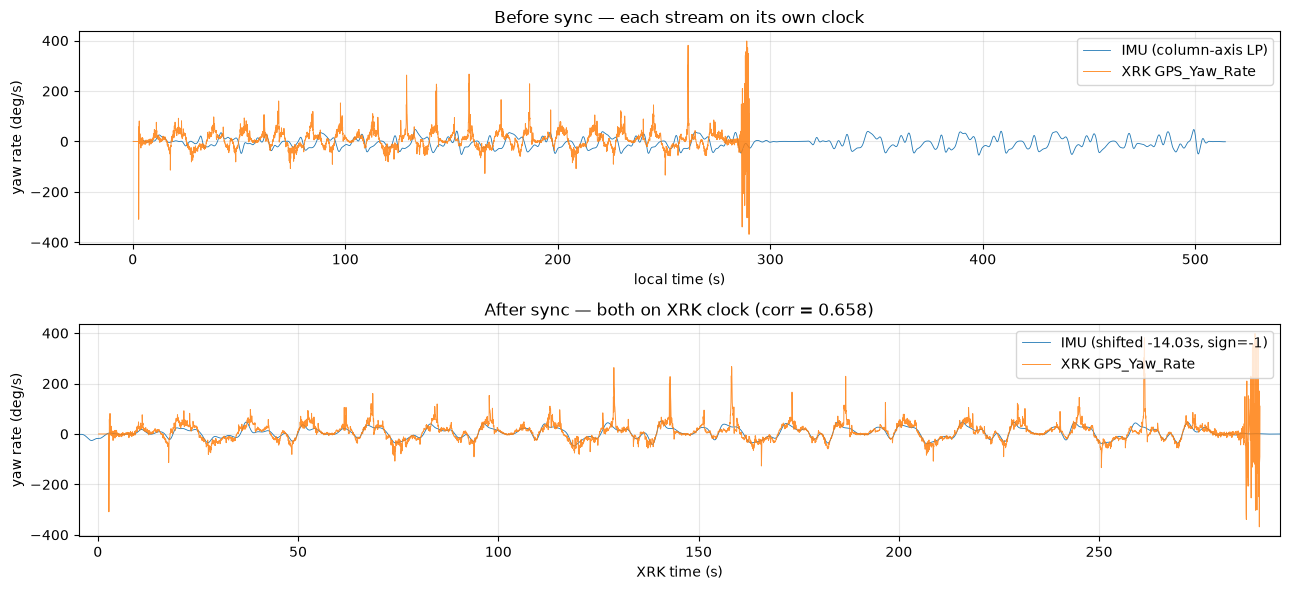

In [6]:
t_imu, yaw_imu, _, _ = chassis_yaw_from_imu(stream)
t_xrk, yaw_xrk = chassis_yaw_from_xrk(log)

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharey=True)
axes[0].plot(t_imu, np.rad2deg(yaw_imu), lw=0.6, label="IMU (column-axis LP)")
axes[0].plot(t_xrk, np.rad2deg(yaw_xrk), lw=0.7, label="XRK GPS_Yaw_Rate", alpha=0.85)
axes[0].set_title("Before sync — each stream on its own clock")
axes[0].set_xlabel("local time (s)"); axes[0].set_ylabel("yaw rate (deg/s)")
axes[0].legend(loc="upper right"); axes[0].grid(alpha=0.3)

# IMU yaw_imu uses the unsigned PCA axis; apply sync.sign here for the overlay.
axes[1].plot(t_imu + sync.offset_imu_to_xrk_s, sync.sign * np.rad2deg(yaw_imu),
             lw=0.6, label=f"IMU (shifted {sync.offset_imu_to_xrk_s:+.2f}s, sign={sync.sign})")
axes[1].plot(t_xrk, np.rad2deg(yaw_xrk), lw=0.7, label="XRK GPS_Yaw_Rate", alpha=0.85)
axes[1].set_xlim(t_xrk[0] - 5, t_xrk[-1] + 5)
axes[1].set_title(f"After sync — both on XRK clock (corr = {sync.corr_peak:.3f})")
axes[1].set_xlabel("XRK time (s)"); axes[1].set_ylabel("yaw rate (deg/s)")
axes[1].legend(loc="upper right"); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

<a id="geometry"></a>
### Body-frame geometry

The column axis (from PCA) and the gravity vector (from quiet samples) give
the tilt factor `k` used to subtract chassis yaw.

In [7]:
quiet = np.linalg.norm(stream.gyro, axis=1) < np.deg2rad(QUIET_RATE_DPS)
g_body = stream.accel[quiet].mean(axis=0)
world_up = -g_body / np.linalg.norm(g_body)
print("Body frame:")
print(f"  column axis:  ({sync.column_axis[0]:+.3f}, {sync.column_axis[1]:+.3f}, {sync.column_axis[2]:+.3f})")
print(f"  world up:     ({world_up[0]:+.3f}, {world_up[1]:+.3f}, {world_up[2]:+.3f})")
print(f"  |g_body|:     {np.linalg.norm(g_body):.3f} m/s²  (gravity ≈ 9.807)")
print(f"  k = |col·up| = {sync.column_tilt_factor:.4f}  →  tilt {sync.column_tilt_deg:.1f}° from vertical")
print()
print("Steering recovery:  ω_steer = (gyro · col_axis) − k · GPS_Yaw_Rate")

Body frame:
  column axis:  (+0.315, -0.030, -0.949)
  world up:     (+0.857, -0.035, -0.514)
  |g_body|:     9.607 m/s²  (gravity ≈ 9.807)
  k = |col·up| = 0.7588  →  tilt 40.6° from vertical

Steering recovery:  ω_steer = (gyro · col_axis) − k · GPS_Yaw_Rate


<a id="laps"></a>
### Lap detection

The XRK beacon markers are unreliable in practice (often only fire once or
twice per session). GPS return-to-start detection is the fallback.

In [8]:
gps_laps = detect_laps_from_gps(log)
xrk_durations = [(e - s) / 1000.0 for s, e in zip(
    log.laps["start_time"].to_pylist(), log.laps["end_time"].to_pylist())]

print(f"XRK beacon detection: {len(xrk_durations)} laps")
for i, d in enumerate(xrk_durations):
    print(f"  lap {i}: {d:6.2f} s" + ("   ← unrealistic" if d > 120 else ""))
print()
print(f"GPS return-to-start detection: {len(gps_laps)} laps")
for i, (s, e) in enumerate(gps_laps):
    print(f"  lap {i}: {s:7.2f} .. {e:7.2f} s   ({e - s:5.2f} s)")

XRK beacon detection: 2 laps
  lap 0:  57.70 s
  lap 1: 232.27 s   ← unrealistic

GPS return-to-start detection: 6 laps
  lap 0:    2.49 ..   56.57 s   (54.08 s)
  lap 1:   56.57 ..  101.13 s   (44.56 s)
  lap 2:  101.13 ..  145.45 s   (44.32 s)
  lap 3:  145.45 ..  190.09 s   (44.64 s)
  lap 4:  190.09 ..  233.53 s   (43.44 s)
  lap 5:  233.53 ..  283.01 s   (49.48 s)


<a id="plots"></a>
### Per-lap plots

Steering is integrated once over the whole recording, then each lap is sliced
out. Per lap: steering angle, kart yaw rate, GPS speed, and the GPS track
colored by speed.

In [9]:
lap_windows, source = choose_lap_windows(sync, force_source="auto")
print(f"Using lap source: {source}  ({len(lap_windows)} laps)")
print()

# Compute the full-recording steering integral ONCE; reuse for every lap.
steering = steering_from_synced(stream, sync)

laps_data = []
for i, window in enumerate(lap_windows):
    lap = extract_lap(stream, sync, window, lap_index=i, steering=steering)
    laps_data.append(lap)
    s = lap_summary(lap)
    print(f"  lap {i}: {s['duration_s']:6.2f}s   "
          f"peak steer ±{s['peak_steer_deg']:>4.0f}°   "
          f"peak yaw rate ±{s.get('peak_yaw_rate_dps', float('nan')):>4.0f}°/s   "
          f"peak speed {s.get('peak_speed_kmh', float('nan')):>5.1f} km/h")

Using lap source: gps  (6 laps)

  lap 0:  54.08s   peak steer ±  64°   peak yaw rate ± 309°/s   peak speed  90.9 km/h
  lap 1:  44.56s   peak steer ±  43°   peak yaw rate ± 161°/s   peak speed 107.1 km/h
  lap 2:  44.32s   peak steer ±  74°   peak yaw rate ± 263°/s   peak speed 108.6 km/h
  lap 3:  44.64s   peak steer ±  57°   peak yaw rate ± 267°/s   peak speed 108.6 km/h
  lap 4:  43.44s   peak steer ±  41°   peak yaw rate ± 125°/s   peak speed 106.9 km/h
  lap 5:  49.48s   peak steer ±  55°   peak yaw rate ± 381°/s   peak speed 108.5 km/h


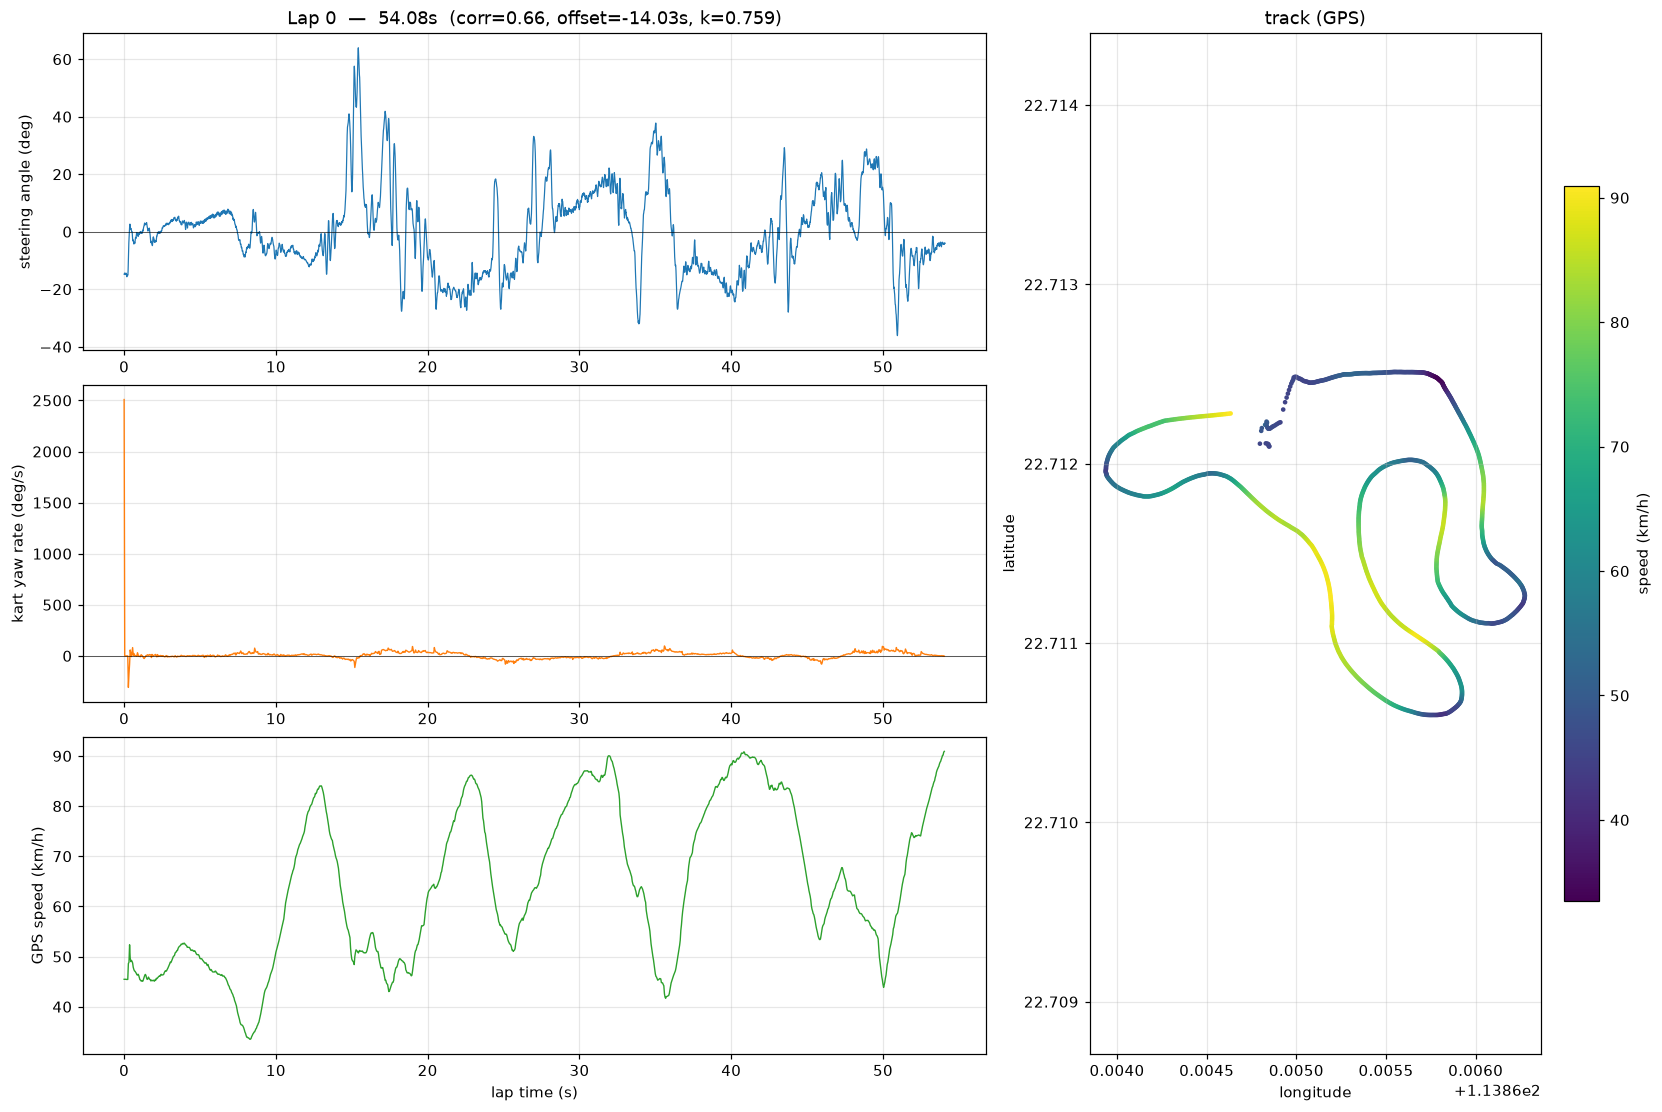

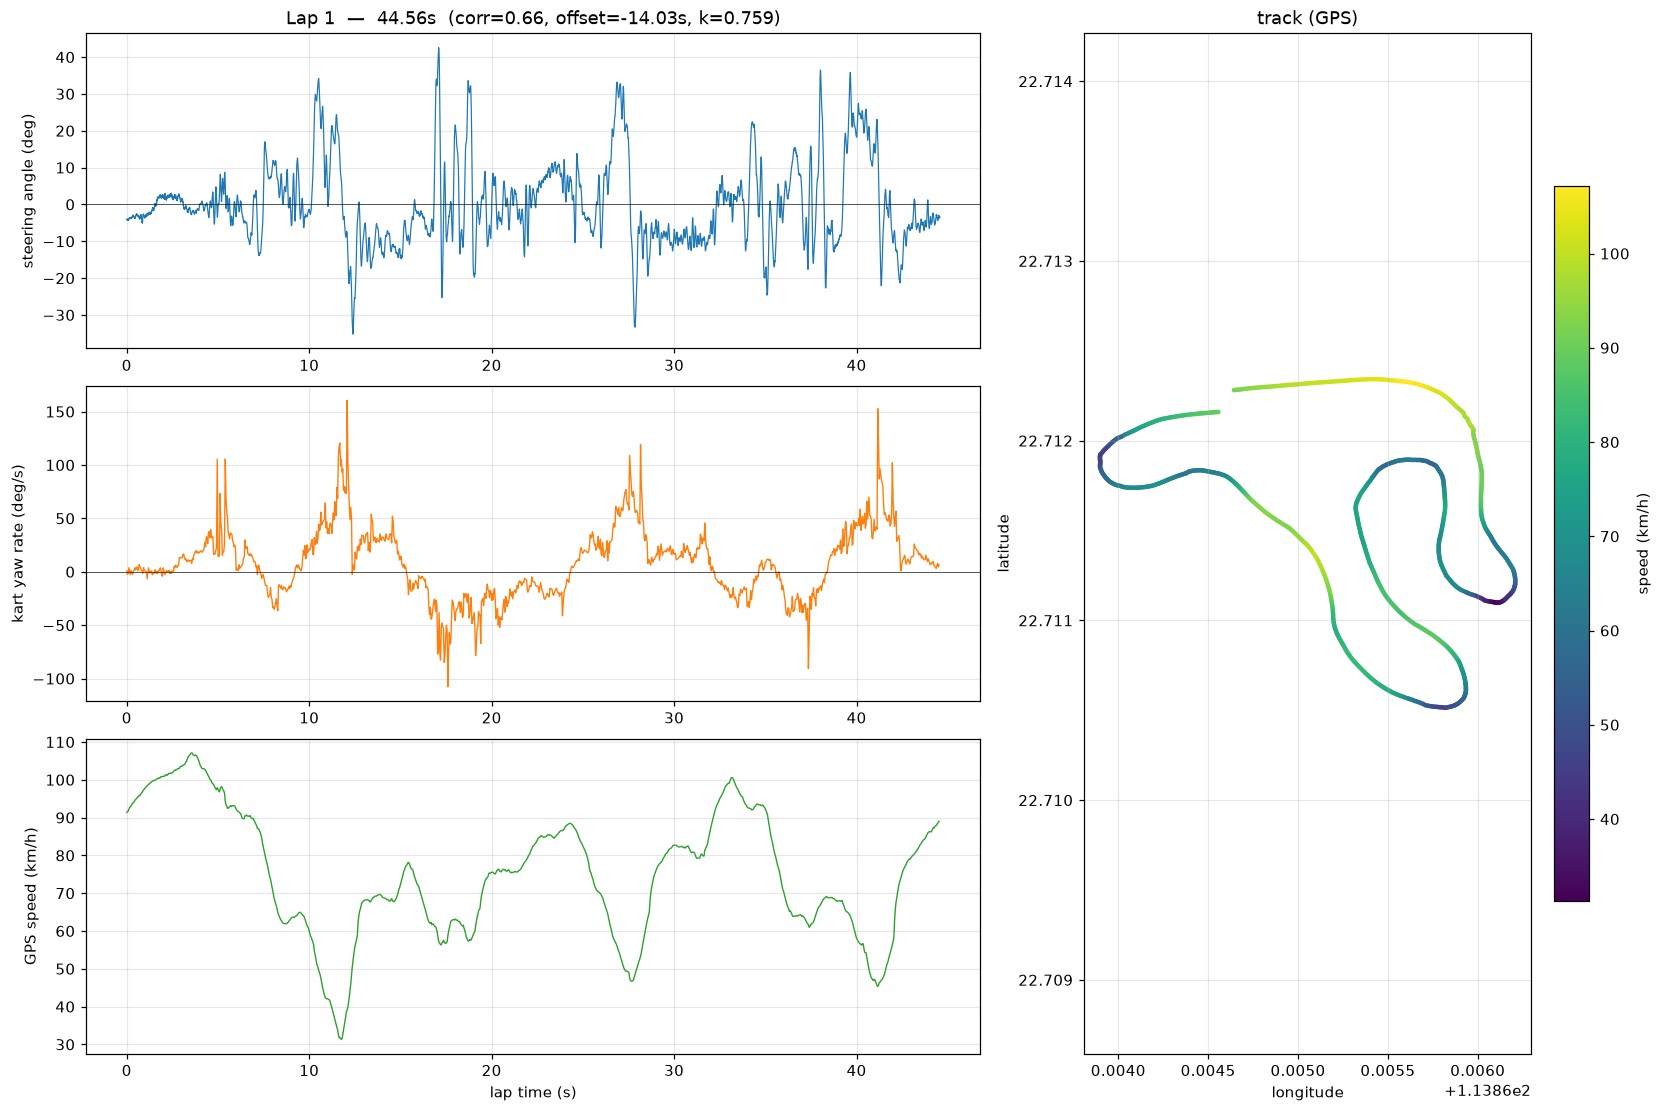

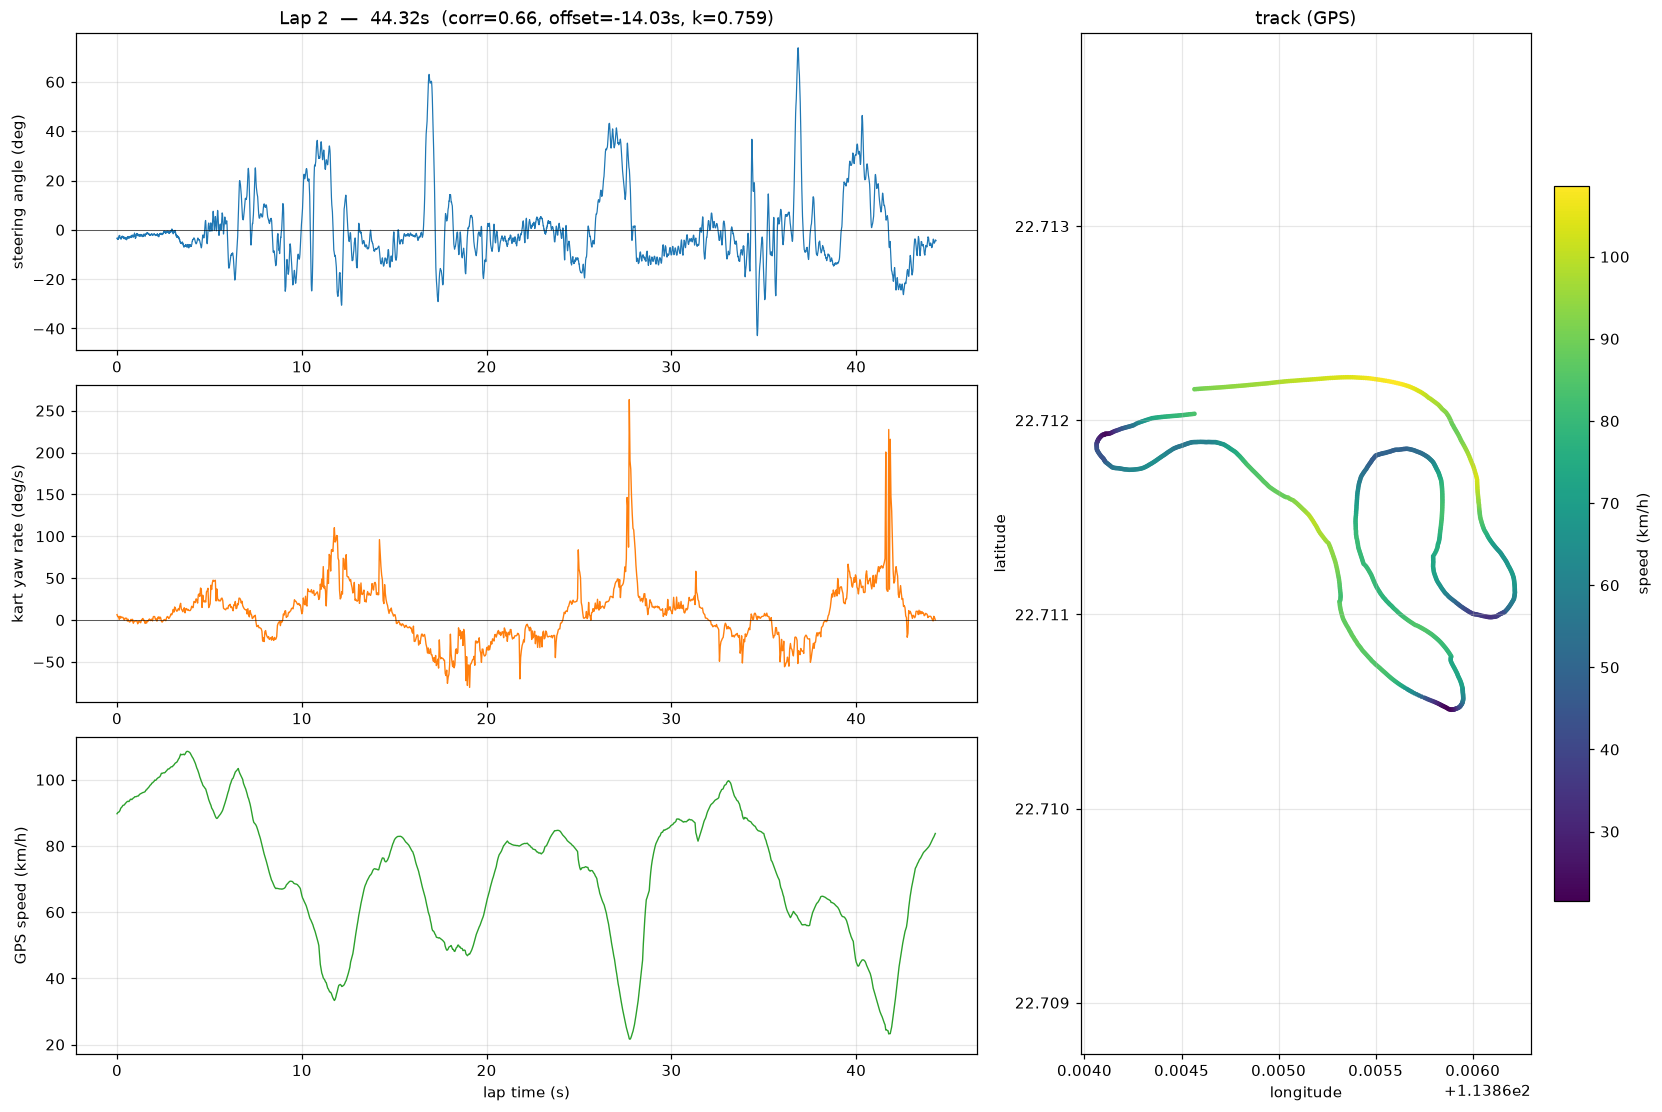

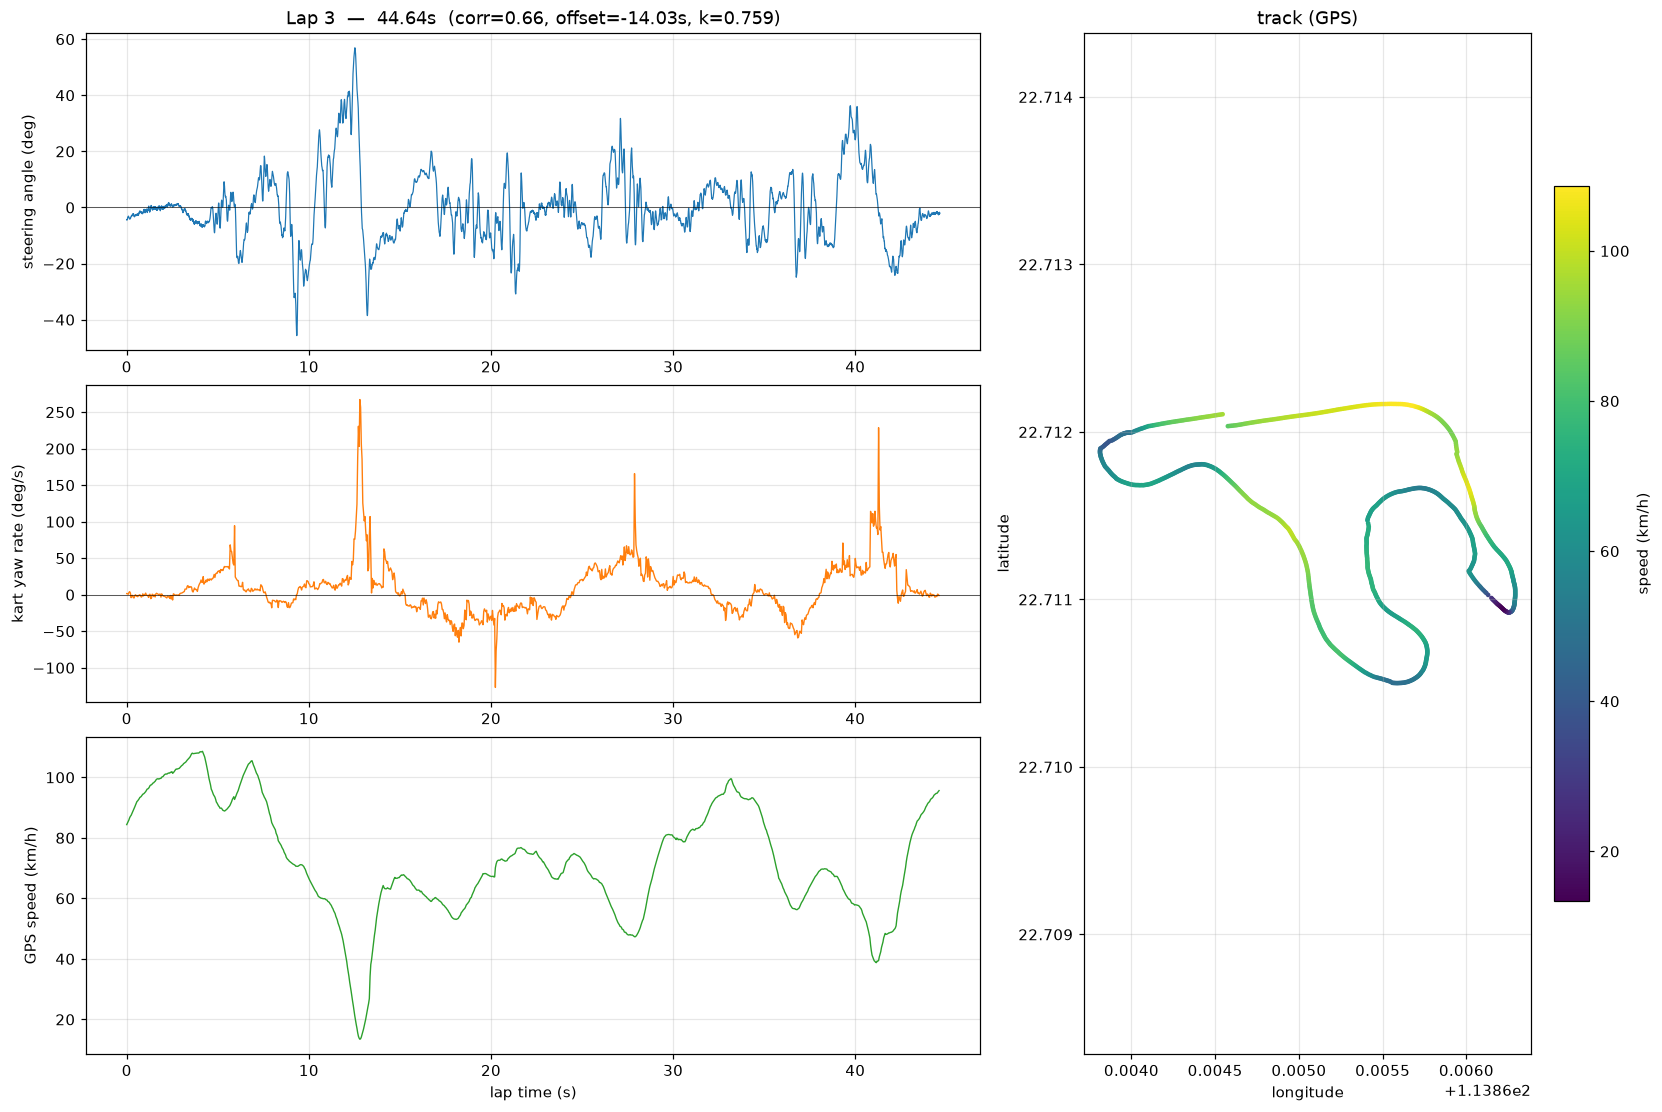

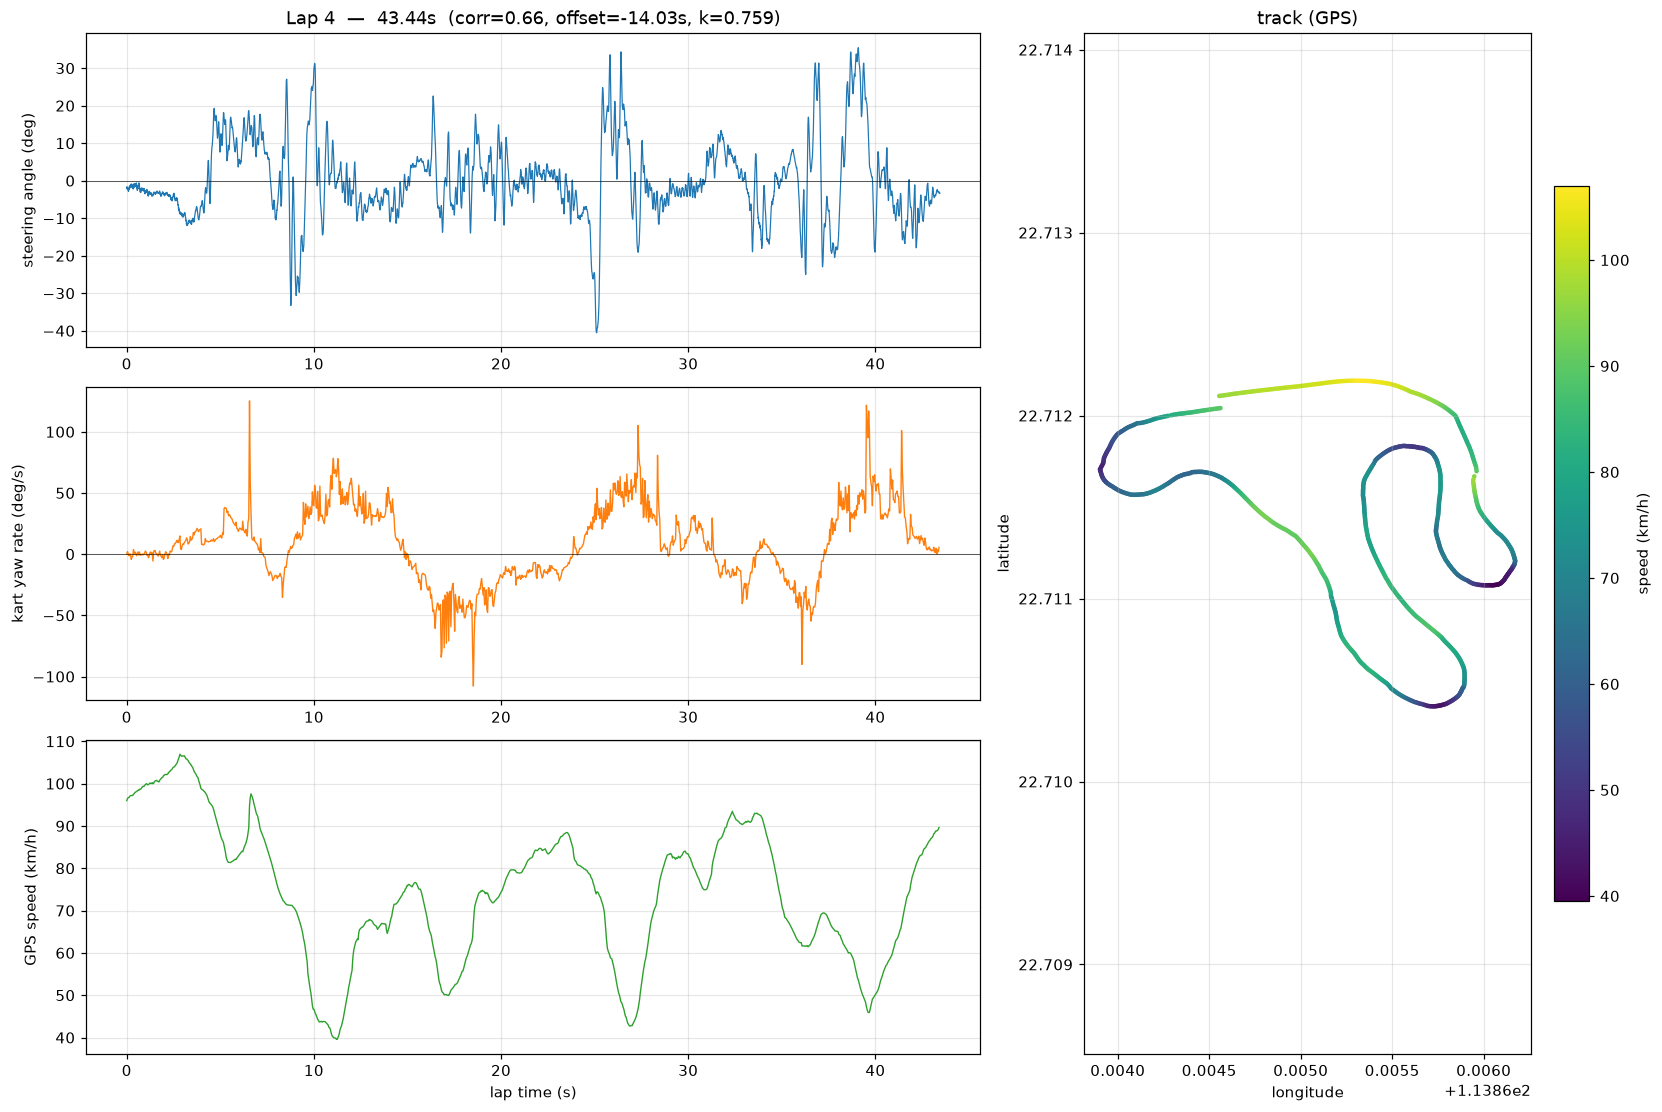

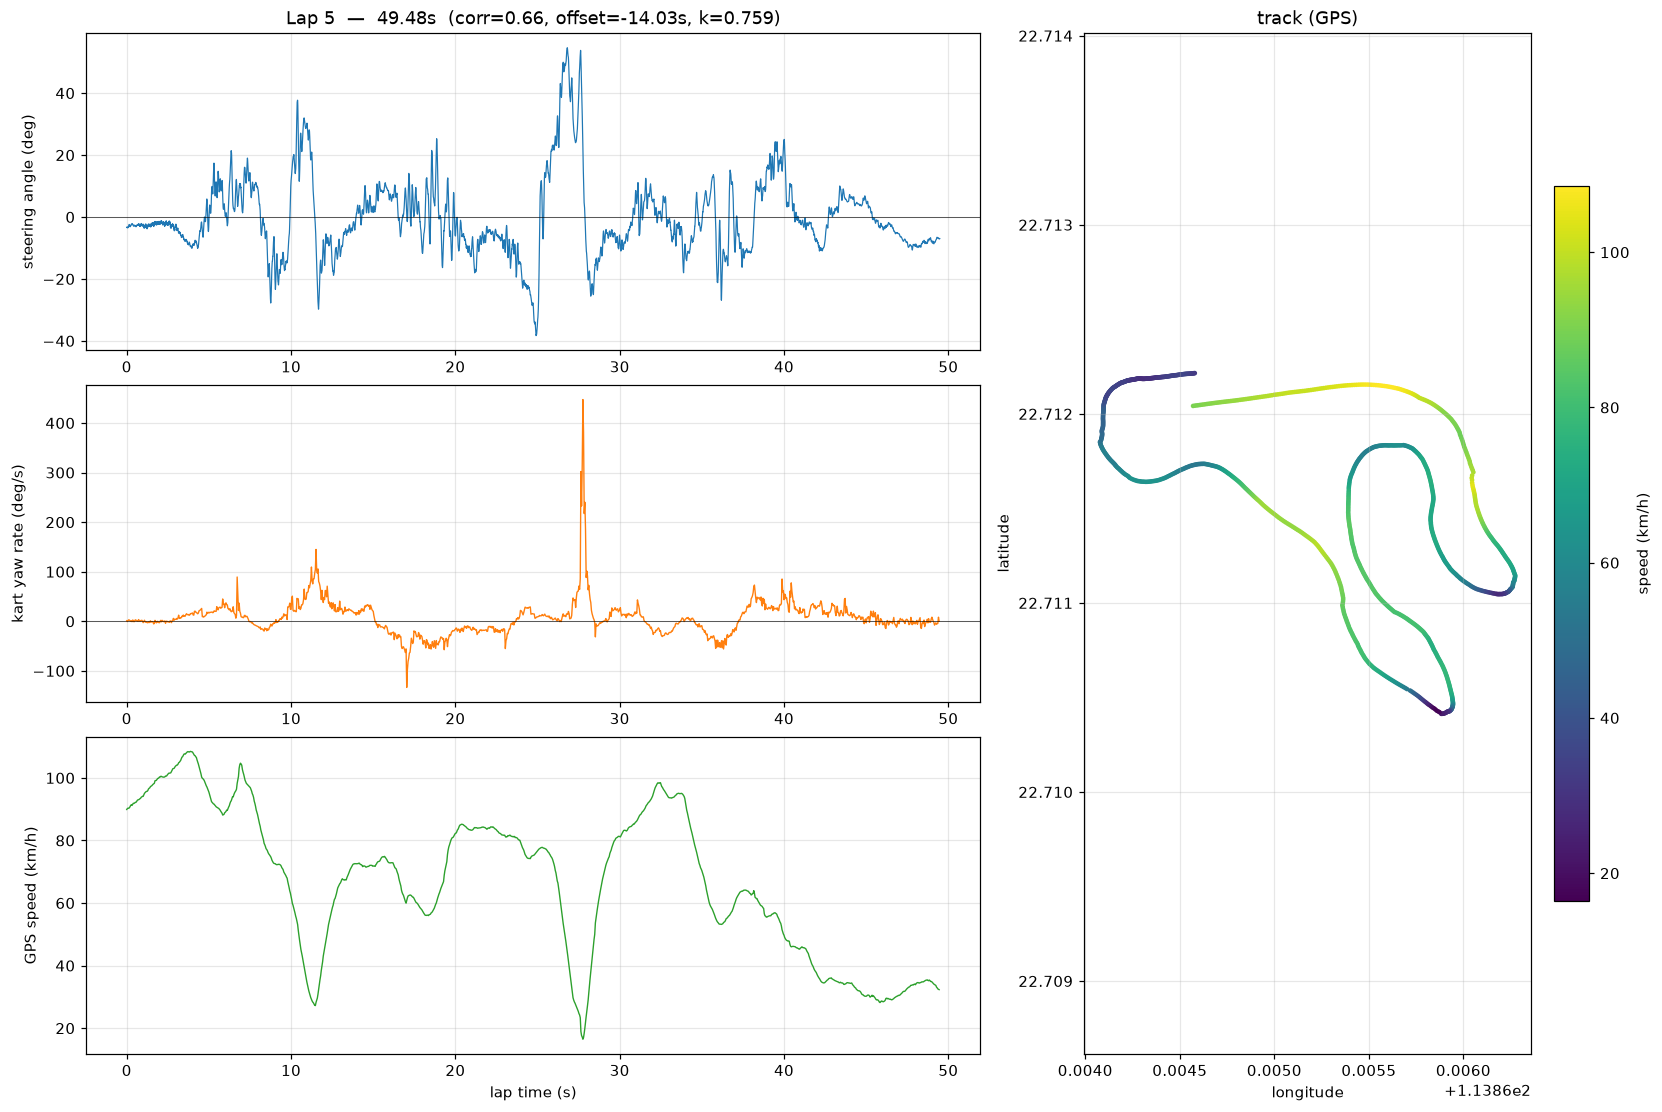

In [10]:
# Render each lap inline. plot_lap writes a PNG and closes its own figure;
# embed it via IPython.display.Image so the notebook creates no extra figures
# to leak. PNGs go to a temp dir cleaned up at the end.
import tempfile
import shutil
from IPython.display import Image, display

_tmp = Path(tempfile.mkdtemp(prefix="kart_laps_"))
try:
    title = (f"corr={sync.corr_peak:.2f}, "
             f"offset={sync.offset_imu_to_xrk_s:+.2f}s, "
             f"k={sync.column_tilt_factor:.3f}")
    for lap in laps_data:
        out_path = _tmp / f"lap{lap.lap_index}.png"
        plot_lap(lap, out_path, title=title)
        display(Image(filename=str(out_path)))
finally:
    shutil.rmtree(_tmp, ignore_errors=True)

<a id="summary"></a>
### Summary table

In [11]:
rows = []
for lap in laps_data:
    s = lap_summary(lap)
    rows.append({
        "lap": lap.lap_index,
        "duration_s": round(s["duration_s"], 2),
        "peak_steer_deg": round(s["peak_steer_deg"], 1),
        "peak_yaw_rate_dps": round(s.get("peak_yaw_rate_dps", float("nan")), 0),
        "peak_speed_kmh": round(s.get("peak_speed_kmh", float("nan")), 1),
        "mean_speed_kmh": round(s.get("mean_speed_kmh", float("nan")), 1),
    })
df = pd.DataFrame(rows).set_index("lap")
df

,duration_s,peak_steer_deg,peak_yaw_rate_dps,peak_speed_kmh,mean_speed_kmh
lap,,,,,
0,54.08,64.0,309.0,90.9,64.2
1,44.56,42.5,161.0,107.1,74.9
2,44.32,73.9,263.0,108.6,71.6
3,44.64,56.9,267.0,108.6,72.4
4,43.44,40.5,125.0,106.9,74.3
5,49.48,54.7,381.0,108.5,66.9


In [12]:
fastest = df["duration_s"].idxmin()
print(f"Fastest lap: {fastest}  ({df.loc[fastest, 'duration_s']} s)")
print(f"  peak steer:     ±{df.loc[fastest, 'peak_steer_deg']}°")
print(f"  peak yaw rate:  ±{df.loc[fastest, 'peak_yaw_rate_dps']}°/s")
print(f"  peak speed:     {df.loc[fastest, 'peak_speed_kmh']} km/h")

Fastest lap: 4  (43.44 s)
  peak steer:     ±40.5°
  peak yaw rate:  ±125.0°/s
  peak speed:     106.9 km/h


<a id="learned"></a>
### What we learned

- **Go 3S IMU runs at 1 kHz**, not ~200 Hz — great for jerk math.
- **Wall-clock sync fails**; cross-correlation of chassis yaw is reliable
  (here the device clocks disagreed by ~17 s).
- **MyChron beacon lap detection is unreliable**; GPS return-to-start works.
- **`GPS Speed` is m/s** in the XRK, not km/h.
- **Naive integration leaks chassis yaw** at corner frequencies — you must
  subtract `k · GPS_Yaw_Rate`, restricted to the IMU/GPS time overlap (a
  high-pass filter alone cannot separate the two).
- **PCA finds the column axis** in body frame for any wheel-mount tilt.

Point `GYROFLOW` / `XRK` at the top at a different session and re-run.